In [9]:
! uv pip install ../.[training] --no-deps

Using Python 3.12.10 environment at: /home/dmp131/anaconda3/envs/cshark
Resolved 1 package in 5ms                                            
   Building cshark @ file:///home/dmp131/C.Shark                       
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
      Built cshark @ file:///home/dmp131/C.Shark               
Prepared 1 package

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from IPython.display import Image

def display_images(image_path1, image_path2):
        # read images
        img_A = mpimg.imread(image_path1)
        img_B = mpimg.imread(image_path2)

        # pad top with white space
        larger = max(img_A.shape[0], img_B.shape[0])
        img_A = np.pad(img_A, ((larger - img_A.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)
        img_B = np.pad(img_B, ((larger - img_B.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)

        # stack
        img = np.concatenate((img_A, img_B), axis=1)
        # save tmp image
        tmp_path = 'tmp.png'
        plt.imsave(tmp_path, img)
        return Image(tmp_path, width=600)

In [3]:
chrom = 'chr2'
start = 500000
region = 'chr2:500000-2500000'

In [10]:
! python ../src/cshark/inference/perturb.py \
    --celltype IMR90_65pct_10kb_deeploop \
    --outname baseline \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/corigami_base.ckpt \
    --seq /home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/dna_sequence \
    --region $region \
    --min-val-pred 0.0 \
    --bigwigs ctcf=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/ctcf.bw \
              atac=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/atac.bw \
    --silent

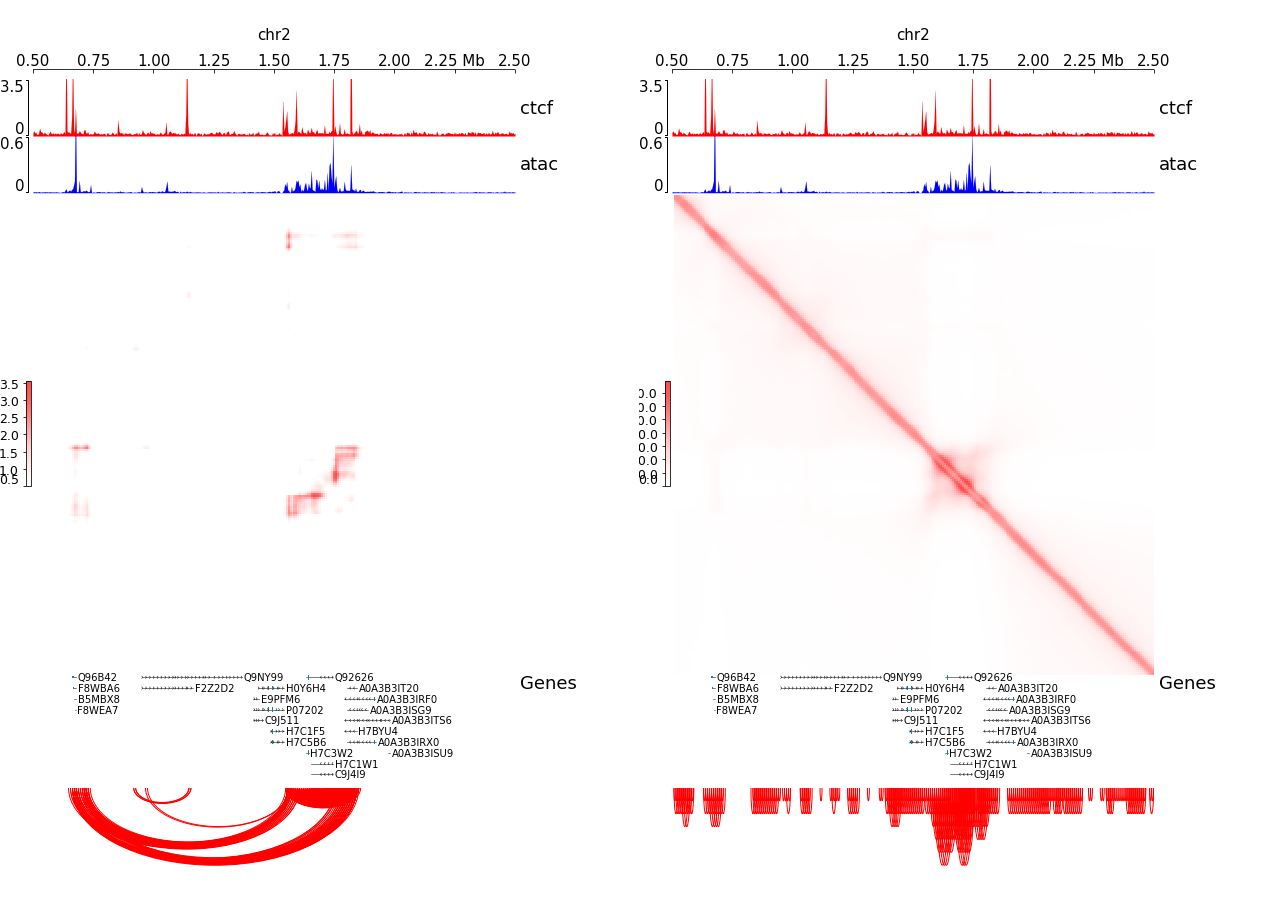

In [11]:
display_images(f'outputs/baseline_IMR90_65pct_10kb_deeploop_{chrom}_{start}_ctcf_true_tracks.png', 
               f'outputs/baseline_IMR90_65pct_10kb_deeploop_{chrom}_{start}_ctcf_pred_tracks.png')

In [12]:
! python ../src/cshark/inference/perturb.py \
    --celltype IMR90_65pct_10kb_deeploop \
    --outname ctcf_ko \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/corigami_base.ckpt \
    --seq /home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/dna_sequence \
    --region $region \
    --ko ctcf \
    --ko-mode knockout \
    --ko-start $start \
    --ko-width 2000000 \
    --min-val-pred 0.0 \
    --bigwigs ctcf=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/ctcf.bw \
              atac=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/atac.bw \
    --silent

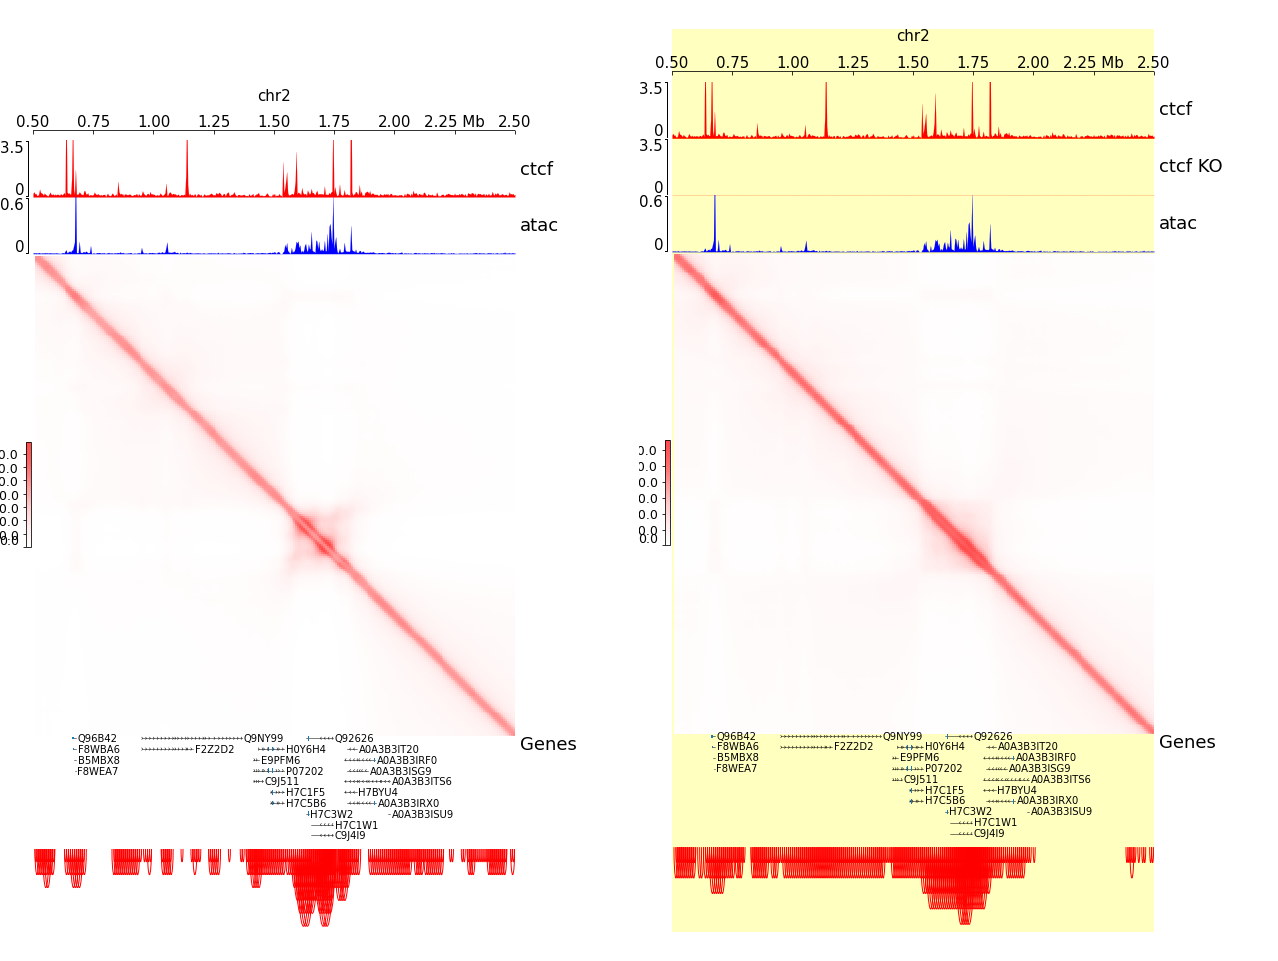

In [13]:
display_images(f'outputs/ctcf_ko_IMR90_65pct_10kb_deeploop_{chrom}_{start}_ctcf_pred_tracks.png',
               f'outputs/ctcf_ko_IMR90_65pct_10kb_deeploop_{chrom}_{start}_ctcf_ko_tracks.png')